# Física Computacional 2 - Métodos de Runge-Kutta

## Equações diferenciais ordinárias - Problema de valor inicial


Considere uma equação diferencial ordinária (EDO) de $1^a$ ordem:
$$
\frac{dy(x)}{dx}=f(x,y),
$$
com a condição inical $y(x_0)=y_0$.

Serão apresentados métodos numéricos para calcular uma aproximação $y_i$ da solução exata $y(x_i)$ do problema de valor inicial nos pontos,

$$
x_i=x_0+ih, \;\; i=0,1,2,\ldots
$$
onde $h$ é o incremento ou passo. Desse modo, a solução numérica do PVI será umja tabela contendo os pares $(x_i,y_i)$ e $y_i\approx y(x_i)$.

## Métodos de Taylor

Fazendo a expansão de Taylor da solução exata $y(x)$, obtemos

$$
y(x+h)=y(x)+\frac{h}{1!}y'(x)+\frac{h^2}{2!}y''(x)+\ldots+\frac{h^n}{n!}y^{(n)}(x)+O(h^{n+1})
$$
Sendo $y'(x)=f(x,y)$, e definindo a função incremento,

$$
\Delta(x,y,h)=f(x,y)+\frac{h}{2!}f'(x,y)+\frac{h^2}{3!}f''(x,y)+\ldots+\frac{h^{n-1}}{n!}f^{(n-1)}(x,y)+O(h^{n})
$$
resulta em
$$
y(x+h)=y(x)+h\Delta(x,y,h)
$$
em que $h\Delta(x,y,h)$ é o incremento exato de $y(x)$ se x for aumentado de $h$.

Como $y(x)$ é função de $x$, a derivada primeira é

$$
f'(x,y)=\frac{d}{dx}f(x,y)=f_x+f_yf,
$$
onde $f=\frac{dy}{dx}=f(x,y)$, $f_x=\frac{\partial f}{\partial x}$ e $f_y=\frac{\partial f}{\partial y}$. As demais derivadas de $f(x,y)$ podem ser calculadas de modo análogo.

Uma aproximação da função incremento $\Delta(x,y,h)$ dada com $q$ termos é

$$
\phi_T(x,y,h)=f(x,y)+\frac{h}{2!}f'(x,y)+\frac{h^2}{3!}f''(x,y)+\ldots+\frac{h^{q-1}}{q!}f^{(q-1)}(x,y).
$$
Deste modo, obtém-se o método de Taylor de ordem $q$,

$$
y_{i+1}=y_i+h\left[f(x_i,y_i)+\frac{h}{2!}f'(x_i,y_i)+\frac{h^2}{3!}f''(x_i,y_i)+\ldots+\frac{h^{q-1}}{q!}f^{(q-1)}(x_i,y_i)\right]
$$

### Método de Taylor de 1a. ordem ( Método de Euler )

O método de Euler é obtido para $q=1$,

$$
y_{i+1}=y_i+hf(x_i,y_i), \;\;\;i=0,1,2,\ldots
$$

### Método de Taylor de 2a. ordem

Para $q=2$ temos,

$$
y_{i+1}=y_i+hf(x_i,y_i)+\frac{h^2}{2!}\left[f_x(x_i,y_i)+f_y(x_i,y_i)f(x_i,y_i)\right], \;\;\;i=0,1,2,\ldots
$$

Note que para $q\ge2$ os métodos baseados em série de Taylor necessitam do cálculo das derivadas parciais da função $f(x,y)$. Isso é desvantajoso computacionalmente, pois esse cálculo depende da forma explícita da EDO, tornando os métodos menos portáveis.


---
<font color='red'> EXERCÍCIO 1 </font> Considere o seguinte PVI:
$$
\frac{dy(x)}{dx}=-xy \;\;\; y(0)=1,
$$
cuja solução analítica é:
$$
y(x)={\rm e}^{-x^2/2}
$$
Obtenha a solução numérica dessa equação diferencial pelos métodos de Euler e Taylor de segunda ordem, comparando com a solução analítica através de um gráfico de $x=0$ até $x=3.$

----

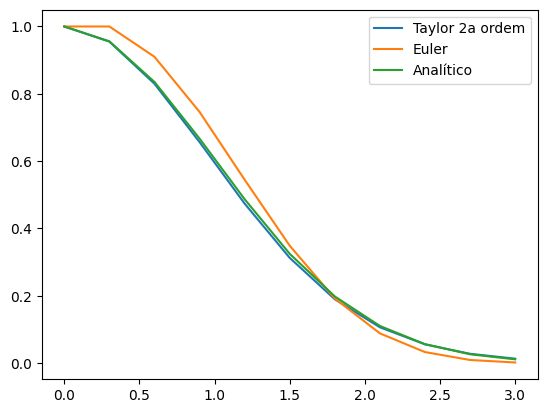

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,y):
  return -x*y

def dfdx(x,y):
  return -y

def dfdy(x,y):
  return -x

def yan(x):
  return np.exp(-0.5*x**2)

N=10
L=3
h=L/N
xgrid=np.linspace(0,3,N+1)
ysol=yan(xgrid)

ynum=np.zeros(N+1)
ynum2=np.zeros(N+1)
#Condição inicial
ynum[0]=1;ynum2[0]=1

# do i=0,N-1
for i in range(N):
  ynum[i+1]=ynum[i]+h*f(xgrid[i],ynum[i])
  ynum2[i+1]=ynum2[i]+h*(f(xgrid[i],ynum2[i])
  +0.5*h*(dfdx(xgrid[i],ynum2[i])+f(xgrid[i],ynum2[i])*dfdy(xgrid[i],ynum2[i])))

plt.plot(xgrid,ynum2,label='Taylor 2a ordem')
plt.plot(xgrid,ynum,label='Euler')
plt.plot(xgrid,ysol,label='Analítico')
plt.legend()
plt.show()


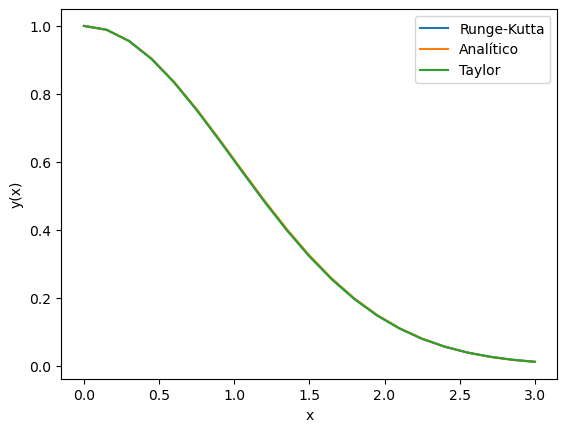

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,y):
    f=-x*y
    return f
N=20
h=3./N
x=np.linspace(0.,3.,N+1)
yanalitico=np.exp(-x**2/2)
y=np.zeros(N+1)

#condições iniciais
y[0]=1. # array para o Ringe-Kutta de 2a ordem
yt2=y # array para o método de Taylor 2a ordem


for i in range(N):
    k1=f(x[i],y[i])
    k2=f(x[i]+h,y[i]+h*k1)
    y[i+1]=y[i]+0.5*h*(k1+k2) # Runge-Kutta de 2a ordem
    yt2[i+1]=yt2[i]+h*(f(x[i],yt2[i])-0.5*h*yt2[i]+0.5*h*x[i]**2*yt2[i]) # Taylor de 2a ordem
    x[i+1]=x[i]+h


plt.plot()
plt.plot(x,y,x,yanalitico,x,yt2)
plt.legend(["Runge-Kutta", "Analítico","Taylor"])
plt.xlabel('x')
plt.ylabel('y(x)')

plt.show()


## Métodos de Runge-Kutta

A mesma precisão dos métodos de Taylor pode ser alcançada pelos métodos de Runge-Kutta sem a necessidade de se calcular as derivadas parciais explicitamente. A ideia é calcular $f(x,y)$ em uma série de pontos estratégicos escolhidos no intervalo $(x,x+h)$ de modo que a precisão seja correspondente a um dado método de Taylor.

### Métodos de Runge-Kutta de 2a. ordem

Seja a aproximação para a função incremento dada por

$$
\phi_{RK}(x_i,y_i,h)=b_1k_1+b_2k_2
$$
onde
$$
k_1=f(x_i,y_i)
$$
e
$$
k_2=f(x_i+c_2h,y_i+a_{21}hf(x_i,y_i))
$$

Agora, expandimos $k_2$ em série de Taylor em $(x_i,y_i)$ e retemos os termos de derivada primeira,

$$
f(x_i+c_2h,y_i+a_{21}hf(x_i,y_i))\approx f(x_i,y_i)+c_2h\frac{\partial f(x_i,y_i)}{\partial x}+a_{21}h\frac{\partial f(x_i,y_i)}{\partial y}f(x_i,y_i)+O(h^2)
$$
Substituindo em $\phi_{RK}$ e rearranjando,
$$
\phi_{RK}(x_i,y_i,h)=(b_1+b_2)f(x_i,y_i)+h\left[b_2c_2\frac{\partial f(x_i,y_i)}{\partial x}+b_2a_{21}\frac{\partial f(x_i,y_i)}{\partial y}f(x_i,y_i)\right].
$$

Compare com o incremento do método de Taylor de 2a ordem obtido acima,

$$
\phi_{T}(x_i,y_i,h)=f(x_i,y_i)+h\left[\frac{1}{2}\frac{\partial f(x_i,y_i)}{\partial x}+\frac{1}{2}\frac{\partial f(x_i,y_i)}{\partial y}f(x_i,y_i)\right].
$$

Assim, para os dois métodos terem a mesma precisão temos,

$$
b_1+b_2=1 \\
b_2c_2=1/2 \\
b_2a_{21}=1/2
$$
De fato, pelas duas últimas equações, $c_2=a_{21}$, de modo que,

$$
b_1+b_2=1, \\
b_2c_2=1/2
$$

A partir desse sistema de três variáveis e duas equações pode-se gerar uma infinidade de métodos de 2a. ordem atribuindo um valor arbitrário a uma das variáveis. Por exemplo, com $b_2=1$, $b_1=0$, $c_2=a_{21}=1/2$ é chamado de método de Euler Modificado ou método do ponto médio,

$$
y_{i+1}=y_i+hf\left(x_i+\frac{1}{2}h,y_i+\frac{1}{2}hf(x_i,y_i)\right) \;\;\;i=0,1,2,\ldots.
$$

Outro método de Runge-Kutta de segunda ordem é obtido a partir de $b_2=1/2$, com $b_1=1/2$ e $c_2=a_{21}=1$. Este é o método de Euler melhorado ou método de Heun,

$$
y_{i+1}=y_i+\frac{1}{2}h\left[f(x_i,y_i)+f\left(x_i+h,y_i+hf(x_i,y_i)\right)\right] \;\;\;i=0,1,2,\ldots.
$$


---
<font color='red'> EXERCÍCIO 2 </font> Resolva o PVI do Exercício 1 por um dos métodos de Runge-Kutta de 2a. ordem apresentados acima.

----

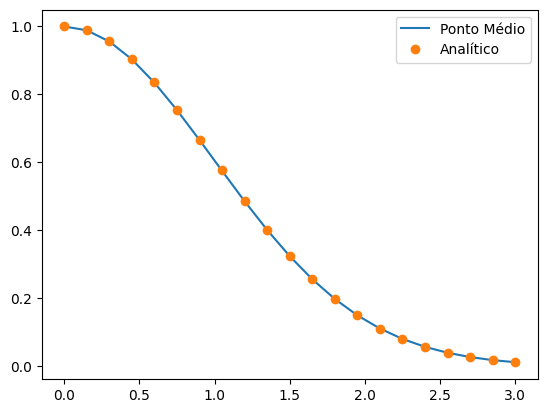

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,y):
    f=-x*y
    return f
N=20
h=3/N
x=np.linspace(0.,3.,N+1)
yanalitico=np.exp(-x**2/2)
y=np.zeros(N+1)
#condições iniciais
y[0]=1. # array para o Ringe-Kutta de 2a ordem

for k in range(N):
  y[k+1]=y[k]+h*f(x[k]+0.5*h,y[k]+0.5*h*f(x[k],y[k]))

plt.plot(x,y,label='Ponto Médio')
plt.plot(x,yanalitico,'o',label='Analítico')
plt.legend()
plt.show()


---
<font color='red'> EXERCÍCIO 3 </font> Considere a seguinte equação de Bernoulli:
$$
\frac{dy(t)}{dt}=k(m-y)y,
$$
com valor inicial $y(0)=1000$, $m=100000$, $k=2×10^{-6}$

Resolva utilizando o método de Runge-Kutta de 2a ordem conhecido como método de Halston dado por

$$
y_{i+1}=y_i+h/3\left(k_1+2k_2\right),
$$
onde $k_1=f(x_i,y_i)$ e $k_2=f(x_i+3h/4,y_i+3h/4k_1)$.

Essa EDO é usada como um modelo simples para predizer o número de infectados por uma doença infecciosa em função do tempo, neste caso medido em dias. O número $m$ é a tamanho da população do local.

----

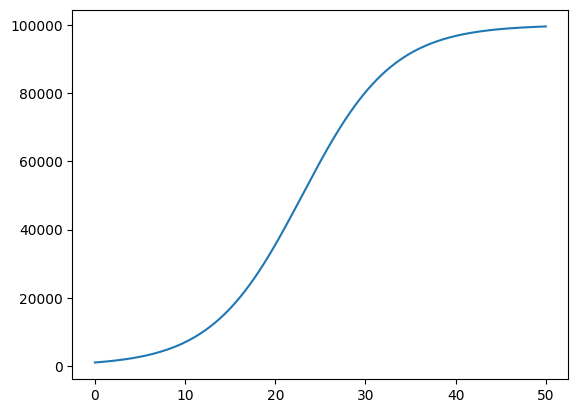

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

m=100000
k=2.e-6

def f(t,y):
  return k*(m-y)*y

N=200
T=50
h=T/N
t=np.linspace(0,T,N+1)
y=np.zeros(N+1)
y[0]=1000

for i in range(N):
  k1=f(t[i],y[i])
  k2=f(t[i]+3*h/4,y[i]+3*h*k1/4)
  y[i+1]=y[i]+h*(k1+2*k2)/3

plt.plot(t,y)
plt.show()







### Métodos de Runge-Kutta de 4a. ordem


O mais conhecido método de Runge-Kutta, é o método clássico de 4a. ordem descrito pelas equações abaixo.

$$
k_1=f(x_i,y_i) \\
k_2=f(x_i+\frac{1}{2}h,y_i+h\frac{1}{2}k_1) \\
k_3=f(x_i+\frac{1}{2}h,y_i+h\frac{1}{2}k_2) \\
k_4=f(x_i+h,y_i+hk_3) \\
y_{i+1}=y_i+\frac{h}{6}\left(k_1+2k_2+2k_3+k_4\right) \;\;\;i=0,1,2,\ldots.
$$
Esse método possui um erro global de truncamento da ordem de $h^4$.

## Sistemas de equações diferenciais ordinárias

Na modelagem de um sistema real, é muito comum o uso de sistemas de EDO's. Isso ocorre principalmente porque uma equação diferencial de ordem $n>1$ pode ser resolvida por meio de um sistema de $n$ equações introduzindo funções auxiliares. Por exemplo, o movimento de uma partícula de massa $m$ em um campo de força $F(t,x)$ é descrito pela equação de segunda ordem,

$$
m\frac{d^2}{dt^2}x(t)=f(t,x).
$$
Se definirmos a função momento linear,
$$
p(t)=m\frac{d x(t)}{dt},
$$
obteremos duas equações acopladas de primeira ordem,
$$
\frac{dx(t)}{dt}=\frac{p(t)}{m} \\
\frac{dp(t)}{dt}=f(t,x)
$$
que são conhecidas como equações de Hamilton.

Essas equações, bem como qualquer sistema de EDO's, podem ser escritas na estrutura vetorial,

$$
\frac{d {\bf X}(t)}{dt}={\bf F}(t,{\bf X}),
$$
onde ${\bf X}(t)=(x(t),p(t))$ e ${\bf F}(t,{\bf X})=(p(t)/m,F(t,x(t)))$. Note que têm que ser dadas duas condições iniciais para definir o PVI, ${\bf X_0}(t=0)=(x_0,p_0)$.

Os métodos vistos anteriormente podem ser facilmente implementados na forma vetorial, como será visto através do exercício abaixo.

---
<font color='red'> EXERCÍCIO 4 </font> Considere o seguinte sistema de equações diferenciais acopladas:
$$
\frac{dx_1(t)}{dt}=\sigma(x_2-x_1),\\
\frac{dx_2(t)}{dt}=x_1(\rho-x_3)-x_2,\\
\frac{dx_3(t)}{dt}=x_2x_1-\beta x_3,
$$
com valor inicial $x_1(0)=0$,$x_2(0)=1$ e $x_3(0)=1.05$. Assuma que $\sigma=10$, $β=8/3$, $\rho=28$, passo h=0.001 e número de pontos N=10000.

Resolva esse sistema utilizando um dos métodos de Runge-Kutta de 2a ordem e escrevas seu código utilizando a forma vetorial, a qual no Python pode ser obtida usando-se listas ou arrays. Faça um gráfico 3D com os pontos $(x_1(t),x_2(t),x_3(t))$. Você verá a seguinte figura:







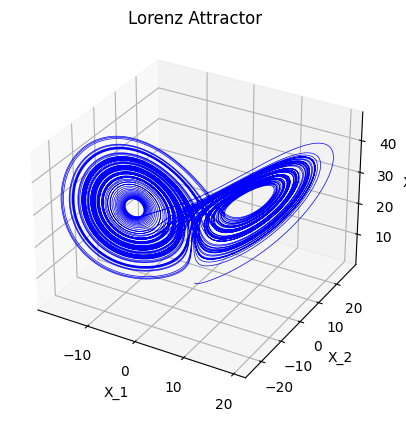

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# parâmetros de Lorentz
sigma=10.
rho=28
beta=8/3

#sistema de equações diferenciais
def f(t,x):
    func=np.zeros(3)
    func[0]=sigma*(x[1]-x[0])
    func[1]=x[0]*(rho-x[2])-x[1]
    func[2]=x[1]*x[0]-beta*x[2]
    return func

# método de Runge-Kutta de 2a. ordem (Heun)
def rk2(t,x,h):
    k1=f(t,x)
    k2=f(t+h,x+h*f(t,x))
    return x+0.5*h*(k1+k2)

# método de Runge-Kutta de 4a. ordem
def rk4(t,x,h):
    k1=f(t,x)
    k2=f(t+0.5*h,x+0.5*h*k1)
    k3=f(t+0.5*h,x+0.5*h*k2)
    k4=f(t+h,x+h*k3)
    return x+h*(k1+2*k2+2*k3+k4)/6


#Parâmetros da solução numérica
h=1.e-3 #0.001
n=100000

#condições iniciais
t=np.zeros(n+1)
x=np.zeros(3)
x[0]=0.
x[1]=1.
x[2]=1.05
x1=np.zeros(n+1)
x2=np.zeros(n+1)
x3=np.zeros(n+1)
x1[0]=x[0];x2[0]=x[1];x3[0]=x[2]
for i in range(n):
    x=rk2(t,x,h)
    x1[i+1]=x[0];x2[i+1]=x[1];x3[i+1]=x[2]
    t[i+1]=t[i]+h


#plt.axes(projection='3d')
#plt.plot3D(x1,x2,x3, 'blue', lw=0.5)
ax=plt.axes(projection='3d')
ax.plot3D(x1,x2,x3, 'blue', lw=0.5)
ax.set_xlabel("X_1")
ax.set_ylabel("X_2")
ax.set_zlabel("X_3")
ax.set_title("Lorenz Attractor")
plt.show()


In [ ]:
z=np.zeros(3)
z[0]=1
z[1]=4
z[2]=5
print(z)


[1. 4. 5.]


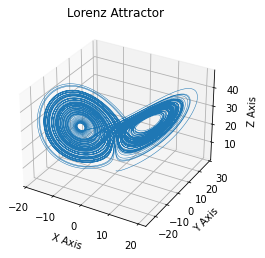